In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2
from IPython.display import Image




***Introduction*** 

Chromatin immunoprecipitation followed by sequencing (ChIP-seq) is a powerful approach to map the DNA-binding patterns of chromatin-associated proteins across the genome. In this experiment, we analyzed ChIP-seq data generated from parental MCF-7 breast cancer cells to identify an unknown protein and infer its biological role through its genome-wide binding profile.The experiment consisted of two biological replicate sample sets, each composed of an immunoprecipitated (IP) sample and its corresponding input control: IP_rep1, INPUT_rep1, IP_rep2, and INPUT_rep2. At the start, only the nature of the protein—a transcription factor—was known, and the goal was to determine its identity and function from its genome-wide binding profile. Using a comprehensive analysis pipeline for quality control, alignment, normalization, peak calling, motif discovery, and enrichment, the protein was revealed to be RUNX1, a transcription factor known to regulate gene expression and chromatin architecture in breast cancer. With our findings, we reproduced key portions of analyses from the publication: RUNX1 contributes to higher-order chromatin organization and gene regulation in breast cancer cells that identified RUNX1 is a direct regulator of MALAT1 and NEAT1 genes, binding at their promoter regions to confirm whether these genes are indeed direct RUNX1 targets in MCF-7 cells.  

***Methods*** 

ChIP-seq data corresponding to parental MCF-7 breast cancer cells were analyzed to identify the protein of interest and its function by characterizing its genome-wide binding sites and patterns using a Nextflow pipeline. The workflow integrated several processes to assess read quality, perform alignment, generate normalized coverage tracks, perform peak calling, visualize binding pattern through signal coverage plotting, and DNA motif enrichment to infer the identity and regulatory function of the bound protein. Through this analysis, the protein was identified as the transcription factor, RUNX1 consistent with the protein of interest in the publication. 

Quality control of raw single-end illumina reads was performed using FASTQC v0.12.1 with default parameters. Adapter and quality trimming of raw reads were performed using Trimmomatic v0.39 in single-end mode, with parameters set to trim adapters present in our passed fasta file using ILLUMINACLIP, remove bases from start and end if quality score is less than 3 (LEADING:3 TRAILING:3), and discarding reads shorter than 36 bps (MINLEN:36) post-trimming. Using Bowtie2 v2.5.4 , we generated an index of the reference genome  and performed alignment of our trimmed reads based on that index with default parameters. We then use Samtools v1.21  to compress the generated bowtie2 SAM file and rearrange it by genomic coordinate with samtools sort. The samtools flagstat utility is then incorporated for quality control, summarizing the alignment statistics by reporting metrics like total read and mapped reads. FASTQC output files, Trimmomatic logs, and samtools flagstat summary files were merged into a single channel and analyzed using MULTIQC v1.25 with default parameters to generate a comprehensive quality control summary. The final preparation for signal quantification, indexed the sorted BAM files using the samtools index utility. 

To begin quantification, a series of operations are done using deepTools v3.5.5 suite. Normalized bigWig coverage tracks were generated using bamCoverage with default parameters. A channel of these bigWigs is passed to the multiBigwigSummary utility, quantifying the read coverage across normalized genomic bins with parameters set to exclude blacklisted regions and output a raw counts file. The plotCorrelation utility then takes the compressed matrix generated by multiBigwigSummary with parameters to generate a heatmap using spearman correlation. 

The biological interpretation of this pipeline applies HOMER v1.21 tools, utilizing our aligned and normalized BAMS to identify enriched regions in a genome our protein of interest binds to further deduce its function and identity. The makeTagDirectory HOMER tool is a preparatory step with default parameters, converting each aligned BAM file to a HOMER readable tag directory. HOMER peak calling was performed using the factor style and specifying the matched input tag directory as the control. For each IP–INPUT pair, tag directories were used to identify enriched regions across the genome, fitting the profile of a transcription factor. The pos2bed.pl utility used default parameters to convert our two peaks files to BED formatted files ideal for downstream analysis. 

Following peak calling, we implemented BEDTools v2.31.1 modules for data processing and filtering. The bedtools intersect tool aims to find reproducible binding events by outputting reproducible peaks found in both files. Parameters are set for producing full length intervals or full peaks. Bedtools intersect is run once more on the generated set of reproducible peaks with parameters to remove genes present in the blacklist file: a list of human reference genome regions that produce artificially high, non-protein specific ChIP-seq signals, for an accurate reproducible, filtered peak file. 

Gene annotation on our set of reproducible filtered peaks is done using HOMER v1.21, mapping each gene in the bed file to its closest gene feature with default parameters. Next, to prepare for visualizing the binding profile of the protein of interest, computeMatrix (deepTools v3.5.5]) computes normalized signal coverage values from the bigWig files across regions, with parameters set to scale 2kb upstream and downstream of genes. The resulting matrix generates a signal coverage plot for each IP sample, using deepTools plotProfile with default parameters. The final visualization analysis uses HOMER’s findMotifsGenome.pl tool to identify the motifs within this protein has specificity for with parameters set to analyze 200 bp regions centered on each peak. 

Functional enrichment analysis was conducted using the GREAT Stanford tool; it was chosen for this analysis because it directly analyzes bed files, assigning biological meaning to non-coding genomic regions by analyzing the annotations of the nearby genes. This approach is ideal for this experiment because RUNX1 binding often occurs at enhancers or promoters, which are non-coding regions, and GREAT is designed to detect these relationships.

***Quality Control Evaluation***

A quality control evaluation of the raw sequencing data, considering the nature of the experiment, is a critical first step to this analysis. ChIP-seq targets to identify a specific subset of the genome, where the protein of interest binds, rather than “random” genomic libraries; with this, certain QC tests are expected to fail but are not necessarily representative of technical failure. MULTIQC was incorporated into the workflow aggregating results from three stages of quality control: FASTQC assessed quality of raw reads, Trimmomatic processed raw reads, removing low-quality regions and adapter contamination specific to this experiment, and samtools flagstat, performed post-alignment evaluated genome-mapping performance. The dataset consisted of four single-end libraries, representing biological replicate pairs (IP and INPUT). The majority total number of reads per library ranged from 28-28.5 million reads per file, with Replicate 2 (Rep 2) presenting as an outlier, sequenced at a substantially lower depth of 10.1 million reads. This discrepancy likely arose from uneven pooling or lower library yield during sequencing, but did not compromise downstream analysis as all libraries maintained high read quality and alignment efficiency. 

The FASTQC reported consistently high Phred scores (median > 30), with expected dips in quality at the first few bases pointing to Illumina calibration. Both IP samples failed the“Per Base Sequence Content”, “Sequence Duplication Levels”, “GC Content” and “Overrepresented Sequence” tests. These results, however, are expected in ChIP-seq. The IP libraries represent DNA fragments enriched for RUNX1 bound regions; transcription factors tend to favor AT-rich regions, and bind very similar or the same motifs along the genome. The Trimmomatic statistics indicated minimal read loss across all libraries, retaining over 90% of reads; IP samples had slightly higher proportions of read trimming, likely due to the shorter fragment lengths of the ChIP-enriched DNA. Flagstat indicated a high-quality alignment was done by Bowtie2, with all libraries aligning >90% of reads to the reference genome. The quality control metrics confirm well-prepared libraries with high-quality sequencing and alignment in the ChIP-seq experiment, suitable for downstream protein identification, and pathway analysis.

***Signal Coverage Plot*** 

The signal coverage plot was generated for each IP sample, to help us visualize the average binding pattern of our protein of interest across all the genes it is bound to. The plot shows how strongly it binds known regions of the genes: near the transcription start site (TSS), within the gene body, or toward the transcription end site (TES). The signal coverage plot allows us to transition our findings from specific binding sites in the genome, given by the peaks, to the protein’s binding-pattern. At this point in the pipeline, we aligned our reads to the genome using Bowtie2, made normalized bigWig files with bamCoverage, and then used computeMatrix with the UCSC gene annotation bed file to line up all genes in a standard manner and average the signal across all genes and see where the protein tends to bind in relation to gene structure (TSS, gene body, TES). In the resulting plot, the x-axis represents the gene structure from 2 kb upstream of the TSS to 2 kb downstream of the TES; the y-axis shows the average normalized signal intensity, indicating how strongly the protein bound across these regions. 

The enrichment signal in both plots around the TSS suggests this protein tends to bind to promoter sequences, supporting a hypothesis that the protein of interest functions as a transcription factor. Transcription factors recognize short DNA motifs near promoters to regulate transcription initiation. Therefore, the sharp peak near the TSS marker confirms the protein’s binding activity links to transcriptional regulation, rather than say chromatin modifications, which typically show enriched signal across the gene body, or histone marks associated with transcription elongation, generating peaks near the TES. 


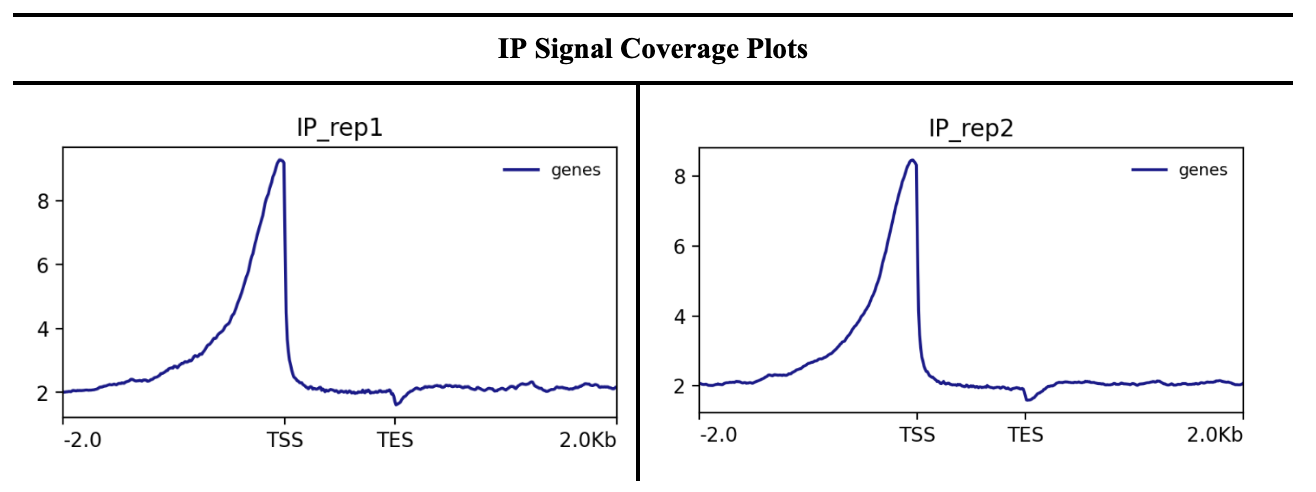

In [2]:
display(Image("/projectnb/bf528/students/rrasmy/project-3-reemrasmy/IP_sig_plots_fig.png"))

***Motif Finding***

Our signal coverage plots confirmed that our protein tends to bind near promoter regions, suggesting it is likely a transcription factor. The next step in our analysis was to identify the specific DNA sequences recognized by this transcription factor. To do this, we used HOMER’s findMotifsGenome.pl to identify the overrepresented DNA sequences (motifs) within the regions that this protein has specificity for. The purpose of this tool is to take our identified peaks and search the surrounding DNA sequences for enriched recurring motifs and ranking them by statistical significance (p-value). Since most transcription factor motifs are within 50-75 bp from the peak center, we used a fixed window size of 200bp to  identify the strongest protein-DNA interactions, while minimizing noise from neighboring sequences. 

The top enriched motif identified was RUNX1, with a p-value of 1e-537, confirming that our peaks correlate to that specific protein of interest. Besides transcriptional regulation, the Runt-related transcription factor (RUNX1) motif is found at promoters and enhancers of many genes, and is involved in hematopoietic differentiation. RUNX1 is essential for normal blood cell development (hematopoiesis) and its dysregulation is involved in various hematological malignancies or blood cancers. Additional forkhead motifs, FOXM1, FOXA1, and FOXA2, were enriched: these transcription factors promote cell-proliferation and are known to cooperate with RUNX1 at promoter and enhancer regions, regulating gene expression during hematopoiesis. The results of this motif analysis helped us use the binding specificity from our ChIP-seq experiment to confirm  RUNX1 as the protein of interest and highlight the likely co-binding transcription factors that support its core functions in blood cell development.


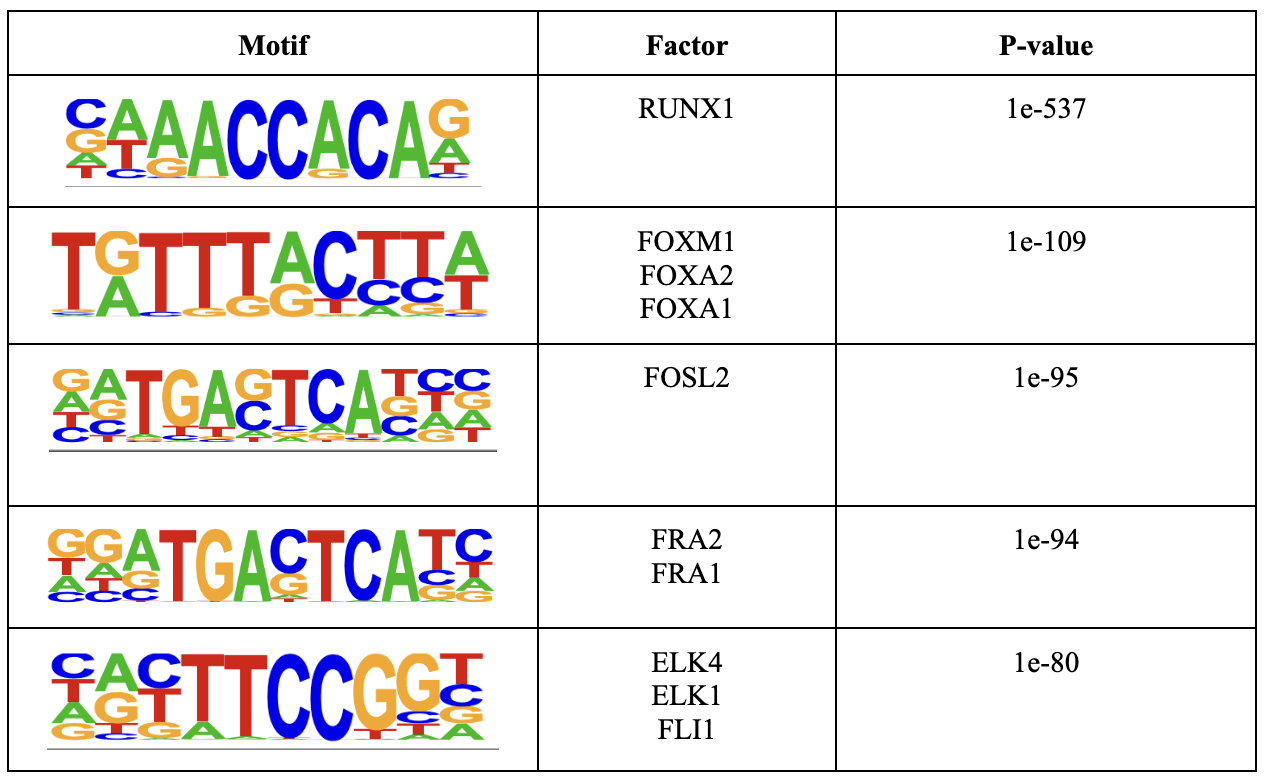

In [3]:
display(Image("/projectnb/bf528/students/rrasmy/project-3-reemrasmy/motifs_fig.png"))

***Overlap ChIP-seq & RNA-seq Results*** 

Our ChIP-seq peak data confirmed that the enriched genomic regions corresponded to RUNX1 binding sites, allowing us to identify RUNX1 as the protein of interest in this experiment. Having identified the factor bound in our ChIP-seq dataset, the next step was to determine how RUNX1 binding influences gene expression across the genome. To explore the impact of RUNX1 binding on gene expression in breast cancer cells, we overlapped our reproducible ChIP-seq peaks with the published RNA-seq log₂ fold-change dataset (GSE75070) to reproduce the analyses shown in Figure 2 of the paper. Through this integration, the goal is to address:  when RUNX1 is knocked down, which genes change expression and how many of those genes have ChIP-seq peaks near them? 

To prepare our data for mirroring the publication’s findings, we loaded the RNA-seq matrix into a pandas dataframe and applied thresholds consistent with the publication (|log₂FC| > 1 and padj < 0.01), extracting the significant genes. We then added a new “direction” column to this copy of the dataframe and classified genes as “up” or “down” regulated. A separate dataframe was created from the annotated peaks file, where the Gene Name column was standardized in preparation for comparing the gene names present in the ChIP-seq and RNA-seq dataframe. Finally, to find the genes that both change expression and have ChIP-seq peaks near them, a new column was added the RNA-seq dataframe called “has_peak” that used the isin() function to check whether each gene in the RNA-seq results appeared in the annotated peaks list of genes. This modified dataframe contained the essential information for replicating the findings in Figure 2D-F.

Figure 2F visually presents an idea in the paper of  “RUNX1 Bound”,  that a gene is more likely to be directly related to a TF like RUNX1, if either the TF binds near the promoter (TSS) or somewhere in the gene body. We replicated the “+\- 5kb of TSS” portion of the figure, identifying a gene as “RUNX1 Bound” if there is a ChIP peak 5000 bp up or downstream of the TSS. The total number of up and downregulated genes, 687 and 466 we generated respectively, were consistent between our analyses and the paper. However, we detected 75 RUNX1- bound upregulated and 53 RUNX1-bound downregulated, which differ from the 59 and 48 reported in the paper. Several factors likely contributed to this difference. First, and likely the primary reason, the paper used a strict ±5 kb window around TSSs, whereas our HOMER-based annotation assigns peaks to their nearest promoter regardless of the exact distance cutoff, likely leading to more genes labeled as RUNX1-bound. Another reason could be the original study aligned on the hg19 genome build, whereas our pipeline used the GRCh38 assembly. GRCh38 contains updated additional promoter coordinates, which expands the number of genes that fall within promoter regions. The rationale behind combining these two analyses is to distinguish direct RUNX1 transcriptional targets from indirect effects of the knockdown. ChIP-seq alone identifies where RUNX1 binds in the genome, but it can’t reveal which of those binding events actually influence gene expression. Conversely, RNA-seq reveals which genes change expression after RUNX1 depletion, but it does not identify why those genes change or whether RUNX1 is directly responsible. Overlapping the techniques allows us to identify more complex conclusions like whether RUNX1 tends to activate or repress its targets, in the context of this paper, providing a more informative picture of its regulatory role in MCF-7 breast cancer cells. 

Figures 2D and 2E present genome browser comparative analyses of RUNX1 ChIP-seq peaks, and RNA-seq peaks at specific genes: NEAT1 and MALAT1: gene expression regulating lncRNAs whose promoters are strongly bound by RUNX1 and were significantly downregulated following RUNX1 knockdown. The paper uses this figure to support their claim that RUNX1 is mainly a transcriptional activator in this cell context. To replicate the ChIP-seq portion of Figures 2D and 2E, we loaded the IP and input bigWig tracks from each replicate, along with our reproducible peak set, into IGV. The difference in reference genomes between our study (hg38) and the paper’s study (hg19) creates non-uniform chromosomal mappings. We then navigated to the MALAT1 and NEAT1 loci and examined RUNX1 signal patterns across replicates to determine whether our data reproduced the binding peaks at the promoters of the selected genes. MALAT1 presented clear IP enrichment relative to the input and a reproducible RUNX1 peak was present near the promoter, consistent with the paper’s findings that MALAT1 is a RUNX1-bound and a significantly down-regulated gene upon knockdown. For NEAT1, however, we observed a visible IP signal upstream of the gene in both replicates; no signal appeared in the reproducible peaks track of the browser.  After checking back to our generated ChIP-seq dataframe of annotated peaks, “NEAT1” was actually not present. This indicated RUNX1 binding at NEAT1 in our dataset did not meet the statistical peak-calling threshold and contrasts the original publications claim, where NEAT1 was identified as a clear RUNX1 target. 


### **Figure 2F**

In [4]:
RNA_seq_data = "GSE75070_MCF7_shRUNX1_shNS_RNAseq_log2_foldchange.tsv"
chip_seq_peaks = "annotated_peaks.txt"

rna_df = pd.read_csv(RNA_seq_data, sep="\t")
# print(rna_df.columns)     # ['genename', 'transcript', 'log2FoldChange', 'padj']


# Applying the thresholds from the paper and creating a copy of the dataframe to analyze that segmnet further
sig_genes = rna_df[(rna_df["padj"] < 0.01) & (rna_df["log2FoldChange"].abs() > 1)].copy()
sig_genes["genename"] = sig_genes["genename"].str.upper()


In [5]:
# Adding an up/down column based on log2FoldChange
sig_genes["direction"] = sig_genes["log2FoldChange"].apply(lambda x: "up" if x > 0 else "down")
# print(sig_genes["direction"].value_counts())    # up: 687, down: 466 -> consistent with paper

upreg_counts = len(sig_genes[sig_genes["direction"] == "up"])
downreg_counts = len(sig_genes[sig_genes["direction"] == "down"])

print(f"Total Upregulated & Downregulated Genes\nUpregulated: {upreg_counts}\nDownregulated: {downreg_counts}")


Total Upregulated & Downregulated Genes
Upregulated: 687
Downregulated: 466


In [6]:
chip_df = pd.read_csv(chip_seq_peaks, sep="\t")
chip_genes = chip_df["Gene Name"].dropna().str.upper().unique()
# print(chip_genes)   # ['ELOCP28' 'KMT2E' 'OVOL2' ... 'TMEM229B' 'ORC4' 'TUBAP4']

In [7]:
sig_genes["has_peak"] = sig_genes["genename"].isin(chip_genes)
print(sig_genes["has_peak"].value_counts())

has_peak
False    1025
True      128
Name: count, dtype: int64


In [8]:
runx1_bound = sig_genes[sig_genes["has_peak"] == True].copy()
print(runx1_bound["direction"].value_counts())

runx1_up_counts = len(runx1_bound[runx1_bound["direction"] == "up"])
runx1_down_counts = len(runx1_bound[runx1_bound["direction"] == "down"])

print("Upregulated RUNX1-Bound Genes:", runx1_up_counts) 
print("Downregulated RUNX1-Bound Genes:", runx1_down_counts)


direction
up      75
down    53
Name: count, dtype: int64
Upregulated RUNX1-Bound Genes: 75
Downregulated RUNX1-Bound Genes: 53


In [9]:
# Organizing the data of interest for replicating Figure 2F in a new dataframe 
runx1_data = {"direction" : ["up", "down"], "RUNX1 Bound": [runx1_up_counts, runx1_down_counts], "Not Bound": [upreg_counts - runx1_up_counts, downreg_counts - runx1_down_counts]}

runx1_df = pd.DataFrame(runx1_data)

sns.set_theme(style="whitegrid")

# heights for bars from your counts
up_bound = runx1_up_counts
up_not   = upreg_counts - runx1_up_counts

down_bound = runx1_down_counts
down_not   = downreg_counts - runx1_down_counts

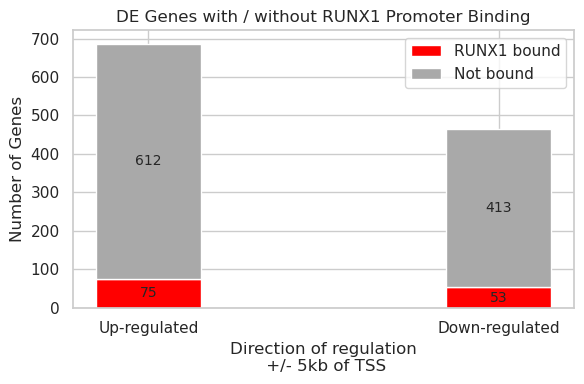

In [10]:
# Generating the stacked bar plot to replicate the stacked bar plot as seen in Figure 2F
plt.figure(figsize=(6, 4))

# UP bar: draw orange (bound) first, then grey (not bound) on top
plt.bar("Up-regulated", up_bound, width = 0.3, color="red", label="RUNX1 bound")
plt.bar("Up-regulated", up_not, width = 0.3, bottom=up_bound, color="darkgray", label="Not bound")

# DOWN bar
plt.bar("Down-regulated", down_bound, width = 0.3, color="red")
plt.bar("Down-regulated", down_not, width = 0.3, bottom=down_bound, color="darkgray")

# This is the code to have the counts inside the bars 
# Up-regulated
plt.text("Up-regulated", up_bound/2, str(up_bound), ha="center", va="center", fontsize=10)
plt.text("Up-regulated", up_bound + up_not/2, str(up_not), ha="center", va="center", fontsize=10)

# Down-regulated
plt.text("Down-regulated", down_bound/2, str(down_bound), ha="center", va="center", fontsize=10)
plt.text("Down-regulated", down_bound + down_not/2, str(down_not), ha="center", va="center", fontsize=10)

plt.ylabel("Number of Genes")
plt.xlabel("Direction of regulation\n +/- 5kb of TSS")
plt.title("DE Genes with / without RUNX1 Promoter Binding")
plt.legend()
plt.tight_layout()
plt.show()

### **Figure 2D** 

***MALAT1***

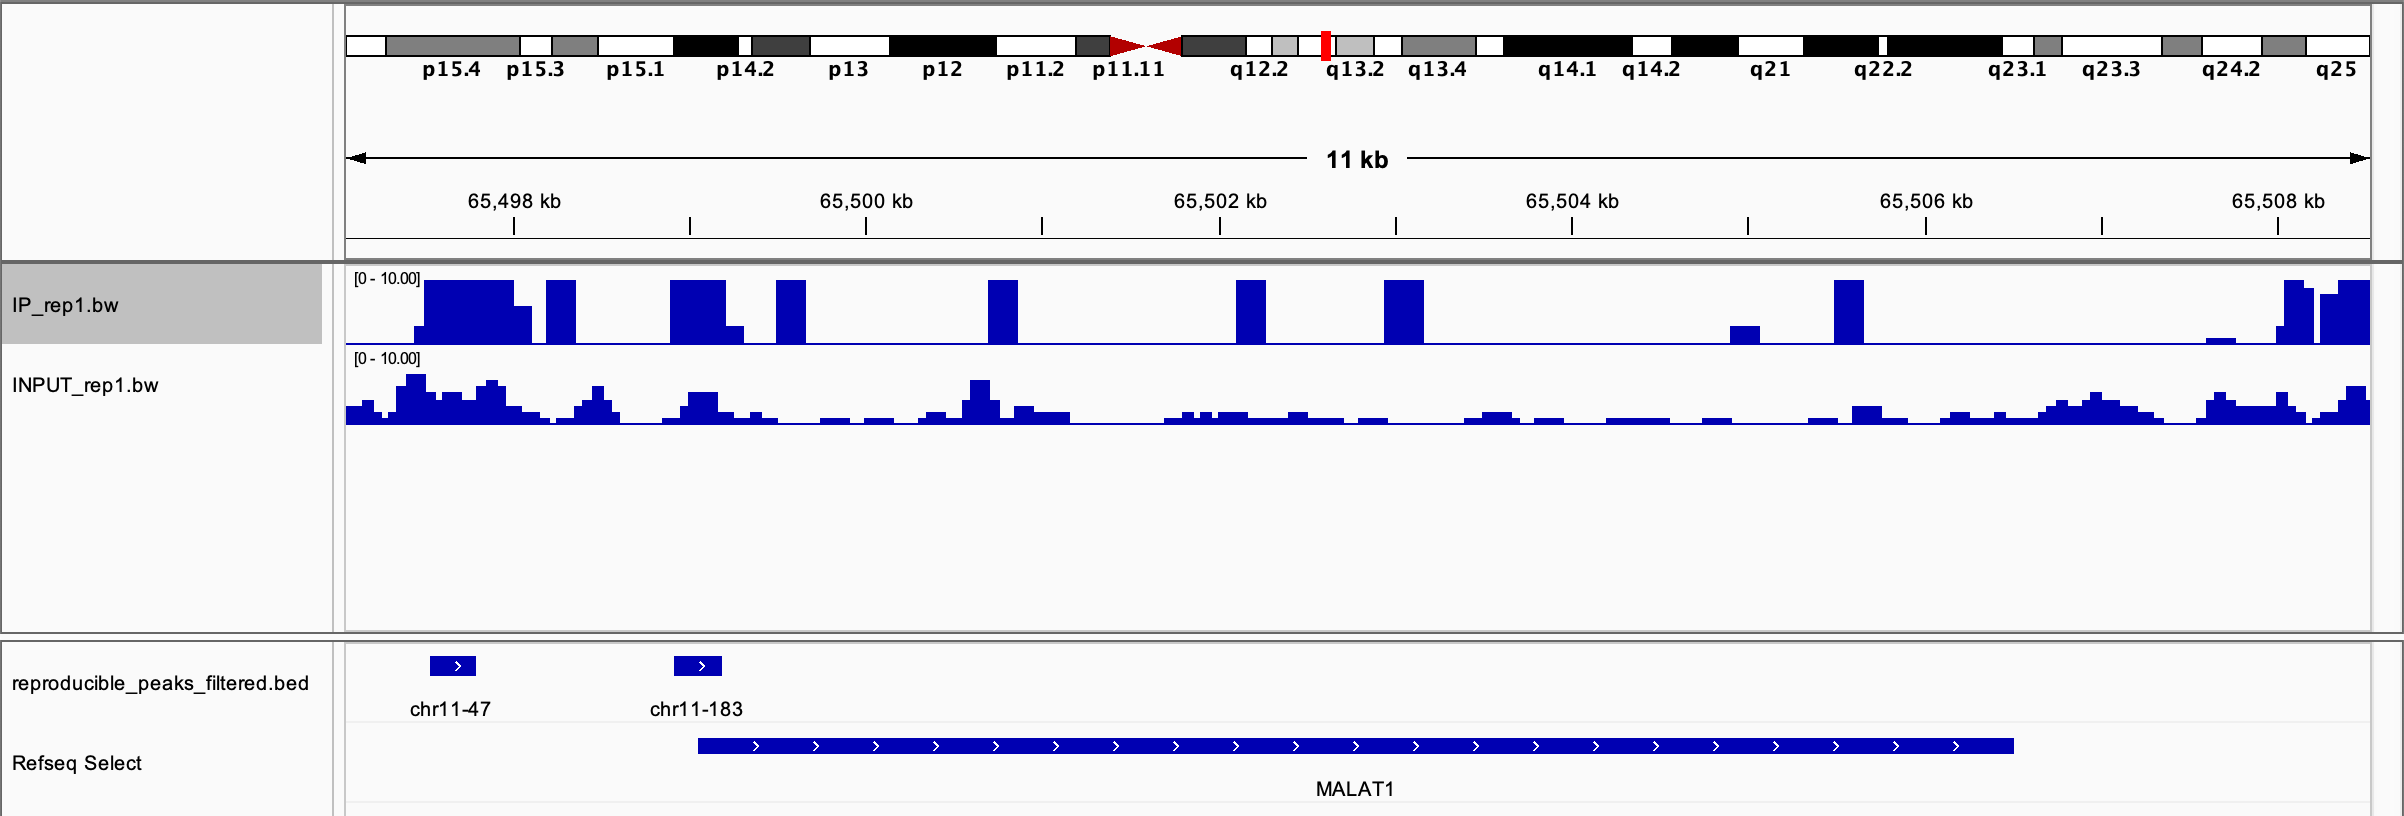

In [11]:
display(Image("/projectnb/bf528/students/rrasmy/project-3-reemrasmy/MALAT1/rep1_MALAT1.png"))
#display(Image("/projectnb/bf528/students/rrasmy/project-3-reemrasmy/MALAT1/rep2_MALAT1.png"))


***NEAT1***

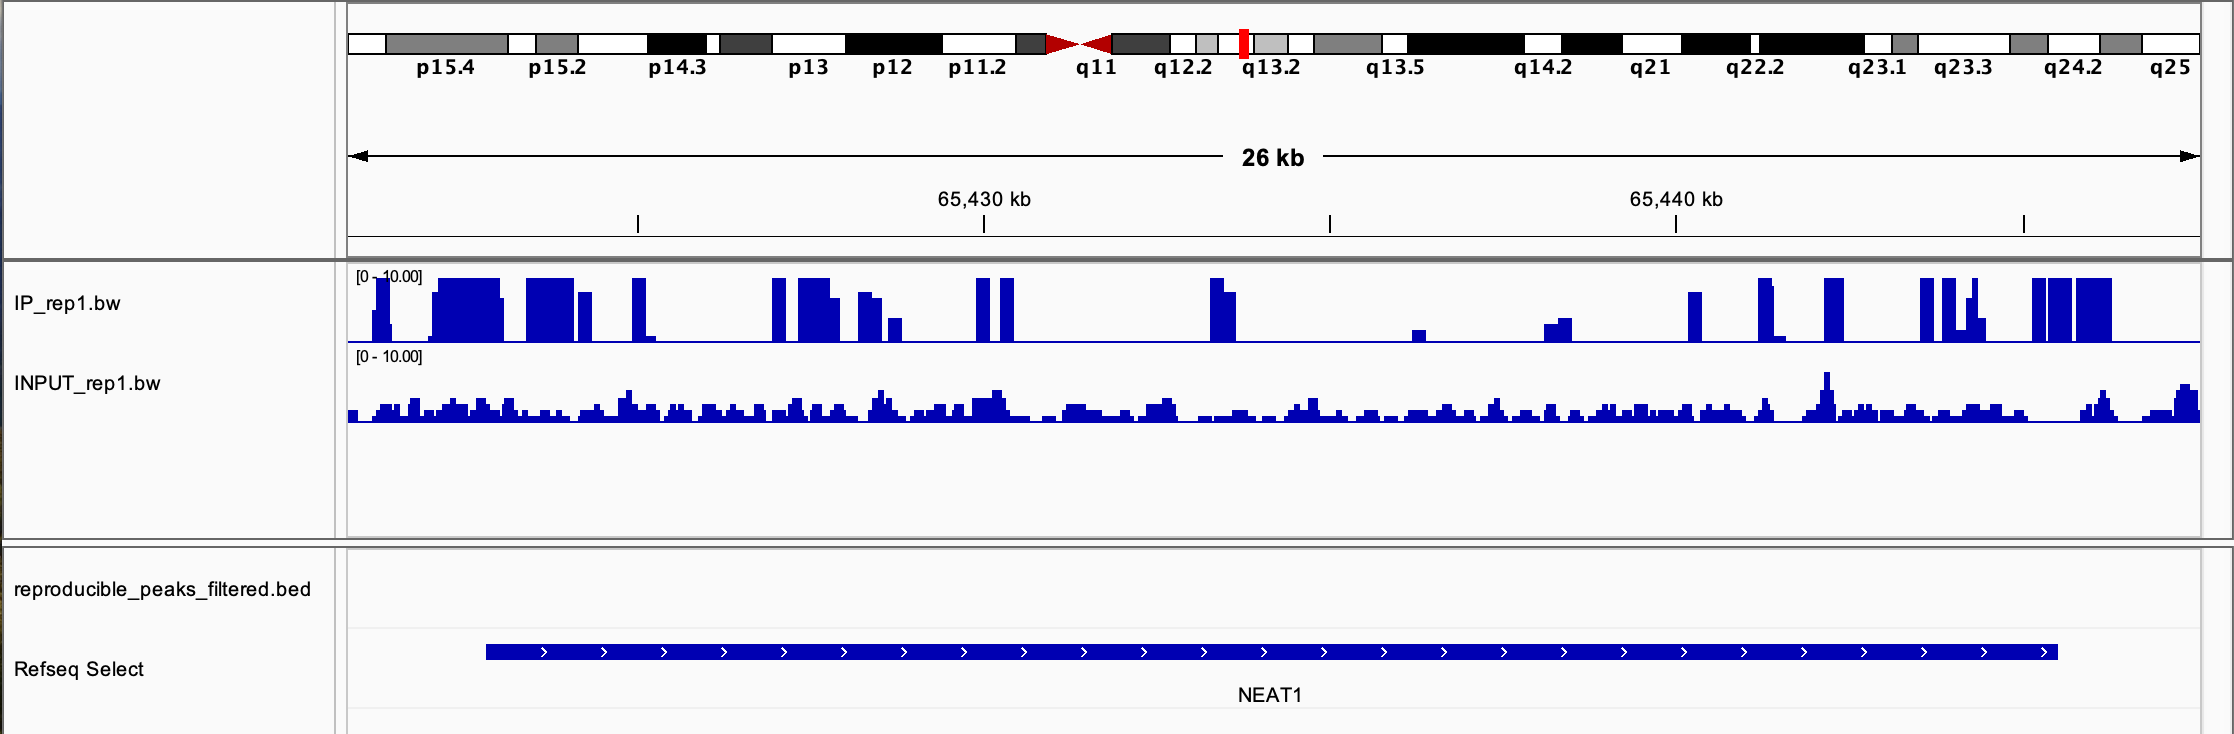

In [12]:
display(Image("/projectnb/bf528/students/rrasmy/project-3-reemrasmy/NEAT1/rep1_NEAT1.png"))
#display(Image("/projectnb/bf528/students/rrasmy/project-3-reemrasmy/MALAT1/rep2_MALAT1.png"))



***Supplementary Figure Comparative Analysis***
 
To assess the reproducibility of our RUNX1 ChIP-seq experiment, we replicated the core quality metric presented in the original publication’s Supplementary Figure 2. Figure S2A presented raw vs. mapped reads for each biological replicate. Reproducing this figure the number of raw reads were consistent with those in the paper, however our number of mapped reads were notably lower than each sample in the publication. This discrepancy could be due to a few factors; the main source likely linked to the parameters set in Trimmomatic;  the paper’s consistent lower percentage of mapped reads could be due to more strict conditions on reads determined to be low-quality. Additionally, the version of Bowtie used could be significant here, as later versions are more permissive than earlier versions, giving us a higher number of mapped reads. 

Figure S2B measures signal similarity across the genome with Pearson correlation matrix. In the context of this ChIP-seq experiment, high correlation between IP and INPUT replicates from each sample would indicate successful immunoprecipitation and reproducibility. Our output correlation plot using deepTools plotCorrelation presents a visually consistent trend to the publication, where IP and INPUT samples clearly cluster together. However, the correlation values are slightly different, and this is likely due to our use of the Spearman method for correlation calculation. The Spearman measures ran-order similarity rather than linear similarity, so its more conservative approach would explain lower correlation values. Another possible explanation could have been differences in genome binning at the multiBigWig summary stage, where a smaller bin size could have amplified background variability, dropping our correlation values. With this, the similarity with the publication supports the author’s takeaway that RUNX1 enrichment patterns are highly reproducible across biological replicates and successful immunoprecipitation, where signal is clearly distinct from background DNA (INPUT). 

Figure S2C quantified and visualized the shared and unique peak sets from the two IP replicates. Peaks unique to each replicate were identified using bedtools intersect -v: the tag returning intervals present in one replicate but not the other, and the lines in each file (rep1_unique.bed, rep2_unique.bed) were counted to get the number of unique peaks in each file. The overlapping peaks were calculated the same way using the reproducible_peaks.bed file originally generated in the pipeline. Our exact peak counts differed from those reported in the original study. These discrepancies are likely linked to differences in peak-calling thresholds and pre-processing of our data. Importantly, the differences are present in the replicate-specific peaks, whereas we observed a similar proportion of reproducible RUNX1 peaks across biological replicates, consistent with the original analysis. 


### **Figure S2A**


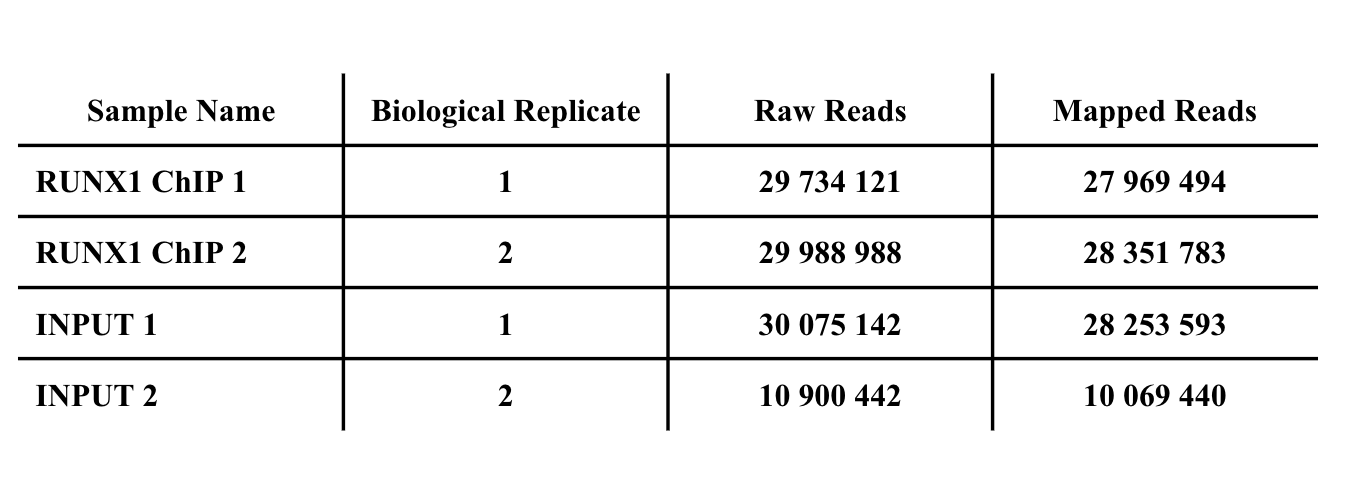

In [13]:
display(Image("/projectnb/bf528/students/rrasmy/project-3-reemrasmy/Figure_S2A.png"))

### **Figure S2B**

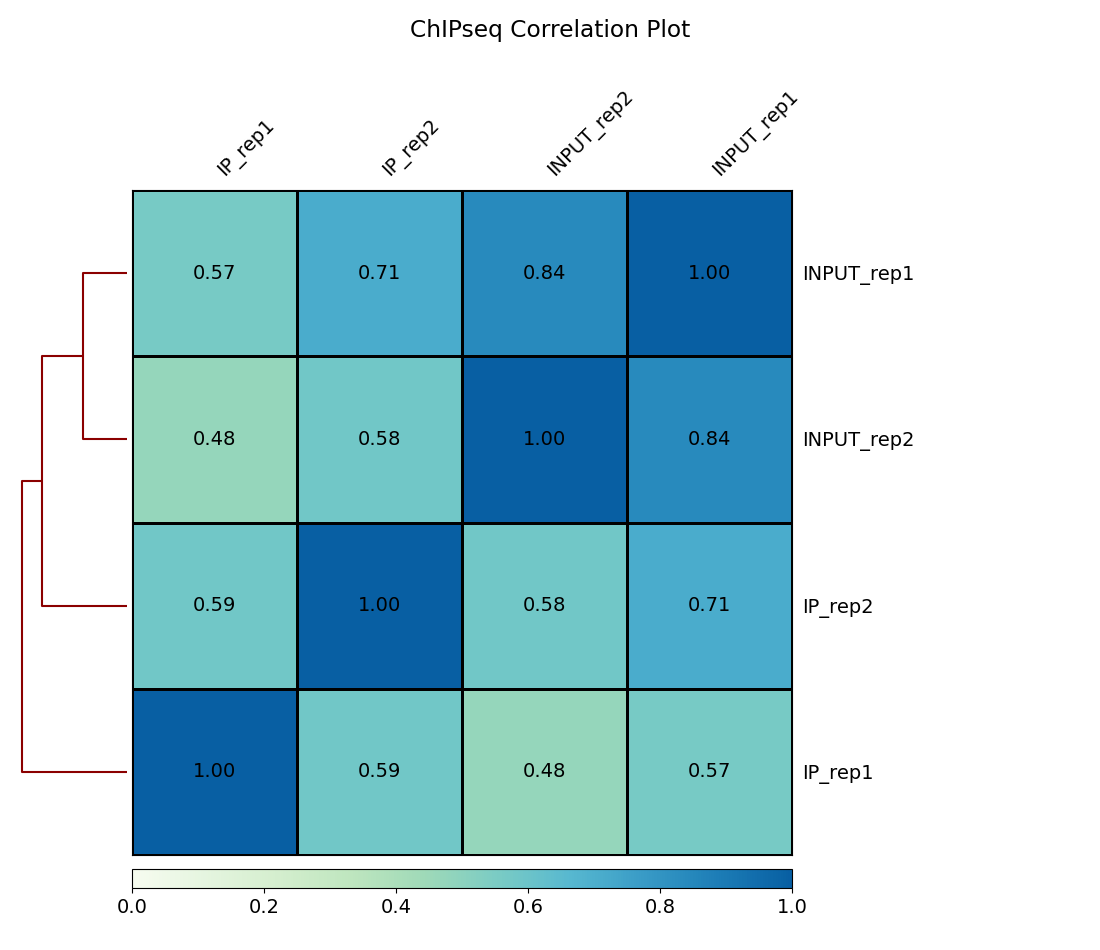

In [14]:
display(Image("/projectnb/bf528/students/rrasmy/project-3-reemrasmy/final_results/correlation_plot.png"))

### **Figure S2C**
 
 *These counts were used to generate the Venn diagram representing unique and shared RUNX1 binding events across replicates.*

 **Commands:**

    *bedtools intersect -u -a peaks_IP_rep1.bed -b peaks_IP_rep2.bed > rep1_unique.bed*

    *bedtools intersect -u -a peaks_IP_rep2.bed -b peaks_IP_rep1.bed > rep2_unique.bed*


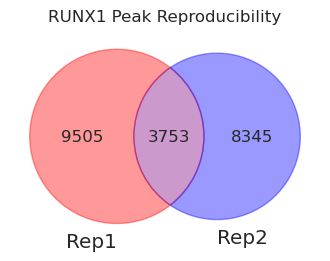

In [15]:
# Generated unique peaks per biological replicate 
rep1_unique = 9505      # from rep1_unique.bed
rep2_unique = 8345      # from rep2_unique.bed
overlap = 3753          # from reproducible_peaks.txt

plt.figure(figsize=(4,4))

venn = venn2(subsets=(rep1_unique, rep2_unique, overlap),
      set_labels=("Rep1", "Rep2"))
venn.get_patch_by_id('10').set_color('red')     # Rep1-only
venn.get_patch_by_id('01').set_color('blue')    # Rep2-only
venn.get_patch_by_id('11').set_color('purple')
plt.title("RUNX1 Peak Reproducibility")
plt.show()

***Enrichment for Annotated Peak Analysis Using GREAT*** 

The final step of our analysis implemented a functional enrichment analysis to investigate the biological functions associated with our RUNX1 peak using the Genomic Regions Enrichment of Annotations Tool (GREAT). This GO Biological Process enrichment analysis technique was selected because it directly analyzes BED-formatted peak files, assigning biological meaning to promoters and non-coding regulatory we were interested in RUNX1 binding throughout our analysis. The analysis set parameters for the hg38 genome build, without filtered reproducible filtered peaks BED file as an input. Enrichment significance was calculated using a binomial test, and the top enriched GO Biological Processes were extracted and visualized as −log10(Binomial p-value) to highlight the most statistically significant biological pathways associated with RUNX1 binding sites. The analysis revealed strong enrichment for developmental and regulatory processes that closely align with known RUNX1 biology. Among the most significant terms were placenta development, embryonic placental morphogenesis, and labyrinthine layer formation aligning to RUNX1’s established roles in embryogenesis and tissue morphogenesis. Additional enriched terms included positive regulation of transcription from RNA polymerase II promoter in response to stress and intrinsic apoptotic signaling mediated by p53, consistent with RUNX1’s function in stress response and cell-fate regulation. Additional mentioned processes related to epidermal differentiation, gliogenesis, and B-cell maturation also align to RUNX1’s documented roles in both epithelial identity and hematopoietic lineage development. Overall, the enrichment results validate that the reproducible peaks captured biologically meaningful RUNX1 binding activity and align well with the functional themes described in the original publication.


In [16]:
# Extracting the gene names from the generated annotated peaks file to input into DAVID and Enrichr
annotated_peaks = open("annotated_peaks.txt",'r').readlines()

header = annotated_peaks[0].strip().split('\t')
gene_name = header.index('Gene Name')
print(gene_name)
genes = []

for line in annotated_peaks[1:]:
    line = line.strip().split('\t')
    genes.append(line[gene_name])

# Wrote a file containing a list of the genes present in the annotated peaks file 
with open("enriched_genes.txt", 'w') as enriched_genes:

    for gene in genes:
        enriched_genes.write(f"{gene}\n")

15


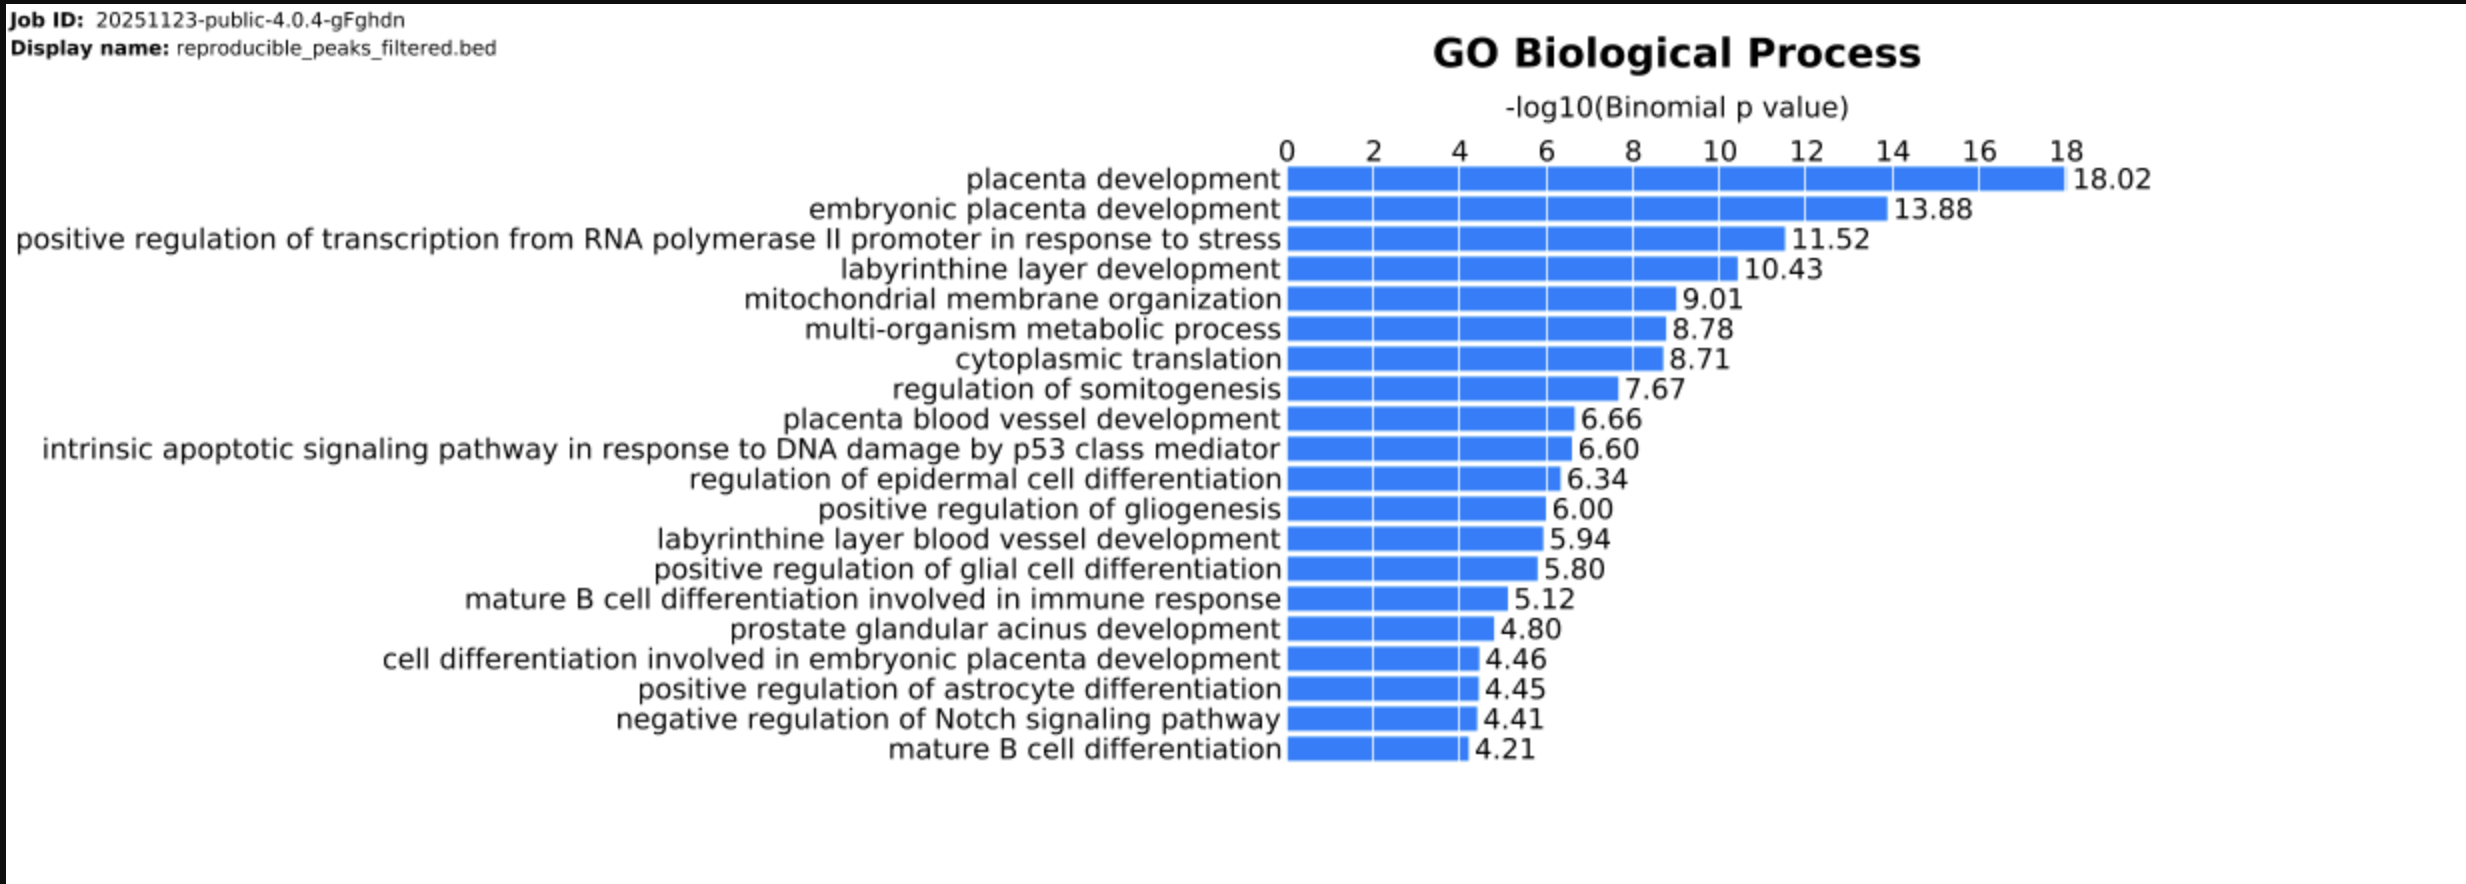

In [17]:
display(Image("/projectnb/bf528/students/rrasmy/project-3-reemrasmy/enrichment_fig.png"))